# View final data
This notebook opens a final data shapefile and prints the dataframe, plots the data and GTN-G outline

In [1]:
import os
import os.path as op
import glob
import sys
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
from shapely.geometry import Polygon
import rasterio as rio
from rasterio.plot import plotting_extent
from earthpy import clip as cl
import earthpy.plot as ep

# set working dir
HOME = op.join(op.expanduser("~"))
os.chdir(os.path.join(HOME, "git/wgms-glacier-project"))

# Set up path to load scripts
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
import scripts.wgms_scripts as ws

In [2]:
# Set region number, region name, and region index
# Once these are set, this notebook should run automatically for the specified region
region_number = 3
region_name = ["Alaska", "Western Canada and USA", "Arctic Canada, North", "Arctic Canada, South", \
               "Greenland Periphery", "Iceland", "Svalbard and Jan Mayen", "Scandinavia", "Russian Arctic", \
               "Asia, North", "Asia, North", "Central Europe", "Caucasus and Middle East", "Asia, Central", \
               "Asia, South West", "Asia, South East", "Low Latitudes", "Southern Andes", "New Zealand", \
               "Antarctic and Subantarctic"]

# Set version number for the final data
final_version = 2

# Plot Region Outline

In [3]:
# Open natural earth basemap TIF file
ne_fp = 'data/natural-earth/NE1_HR_LC_SR_W/NE1_HR_LC_SR_W.tif' # 10 m res
with rio.open(ne_fp) as ne_src:
    # Convert / read the data into a numpy array:
    ne_raster = ne_src.read()
    ne_src_extent = plotting_extent(ne_src)
    bounds = ne_src.bounds
    ne_raster_meta = ne_src.meta
    
# Open glacier regions
glacier_regions_fp = "data/gtn-g-glacier-regions/cleaned/GTN-G_glacier_regions_201707_cleaned.shp"
glacier_regions = gpd.read_file(glacier_regions_fp)

# Extract Region outline
region_outline = glacier_regions[region_number-1:region_number]

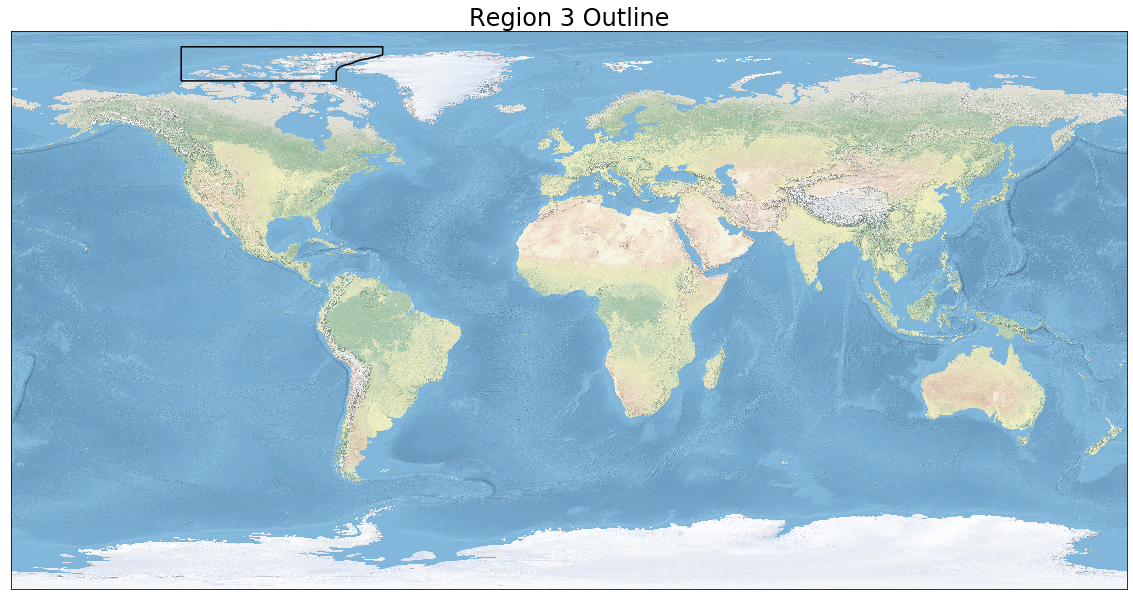

In [4]:
# Plot region outline over the natural earth
# Plot natural earth basemap
fig, ax = plt.subplots(figsize=(20, 20))

# Plot natural earth
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot region outline
region_outline.boundary.plot(ax=ax, color="black")
ax.set_title('Region ' + str(region_number) + ' Outline', fontsize=24)

plt.show()

# View Region Data

## Open Region Data File

In [5]:
# Unzip region glacier file
glacier_zipfile_fn = "data/final-dataset/version-" + str(final_version) + "/region-" + str(region_number) + \
                     "-largest-glaciers.zip"
with zipfile.ZipFile(glacier_zipfile_fn,"r") as zip_ref:
    zip_ref.extractall("data/final-dataset/version-" + str(final_version) + "/unzipped")
    
# Read the extracted shapefile
glacier_shapefile_fn = "data/final-dataset/version-" + str(final_version) + "/unzipped/region-" + str(region_number) + \
                       "-largest-glaciers.shp"
final_glacier_data_df = gpd.read_file(glacier_shapefile_fn)

# Find the centroid of the glacier and add the lat/lon to the dataframe
centroidseries_gl = final_glacier_data_df['geometry'].centroid

## View Dataframe

In [6]:
final_glacier_data_df

,region_no,reg_name,glac_name,glims_id,rgi_id,area_km2,area_src,date,cenlat,cenlon,glims_vers,rgi_versio,geometry
0,3,Arctic Canada North,Wykeham Glacier South,G280449E77998N,RGI2000-v7.0-G-03-04210,3176.024315,A,1999-07-09,78.050991,-79.538778,20250603,7,"POLYGON ((-78.219859 77.972622, -78.2242750000..."
1,3,Arctic Canada North,Devon Ice Cap Southeast Glacier No. 2,G278488E75058N,RGI2000-v7.0-G-03-05172,2622.810586,A,1999-06-15,75.057659,-81.512226,20250603,7,"POLYGON ((-81.502932 75.316999, -81.4818400000..."
2,3,Arctic Canada North,Croker Bay Glacier,G276805E75127N,RGI2000-v7.0-G-03-05208,2170.550046,A,1999-06-15,75.127298,-83.194622,20250603,7,"POLYGON ((-82.555437 75.34082100000001, -82.54..."


## Plot Glacier Outlines

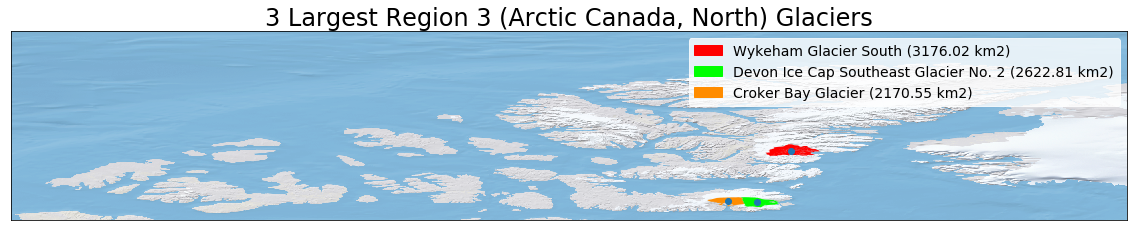

In [7]:
# Set up legends
legend_colors = ['red', 'lime', 'darkorange']
legend_labels = [final_glacier_data_df['glac_name'][0] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][0], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][1] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][1], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][2] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][2], 2)) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
fig, ax = plt.subplots(figsize=(20,20))
minx, miny, maxx, maxy = region_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth basemap
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot 3 largest glaciers from glims dataframe
final_glacier_data_df.iloc[0:1].plot(ax=ax, color='red')
final_glacier_data_df.iloc[1:2].plot(ax=ax, color='lime')
final_glacier_data_df.iloc[2:3].plot(ax=ax, color='darkorange')
ax.set_title('3 Largest Region ' + str(region_number) + " (" + region_name[region_number-1] + ') Glaciers', fontsize=24)

# Plot the center points of the glacier complexes
centroidseries_gl.plot(ax=ax)

# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

plt.show()

## Plot Region Outline with Glacier Outlines

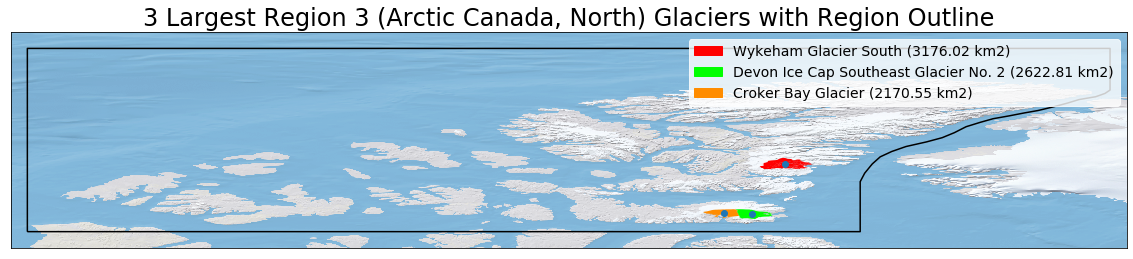

In [8]:
# Plot region outline over the natural earth
# Plot natural earth basemap
fig, ax = plt.subplots(figsize=(20, 20))
# Set up legends
legend_colors = ['red', 'lime', 'darkorange']
legend_labels = [final_glacier_data_df['glac_name'][0] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][0], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][1] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][1], 2)) + ' km2)',
                 final_glacier_data_df['glac_name'][2] + \
                 ' (' + str(round(final_glacier_data_df['area_km2'][2], 2)) + ' km2)']
legend_patches = [Patch(color=icolor, label=label)
                  for icolor, label in zip(legend_colors, legend_labels)]

# Set up plot space
minx, miny, maxx, maxy = region_outline.total_bounds

# Add a little bit to each bound so that you can see the plot of the boundary line
# ****** This doesn't work quite right. It think it needs to be adjusted by which hemisphere/quadrant the glaciers are in
if minx > 0:
    minx = minx + 1
elif minx < 0:
    minx = minx - 1

if maxx > 0:
    maxx = maxx - 1
elif maxx < 0:
    maxx = maxx + 1
    
if miny > 0:
    miny = miny - 1
elif miny < 0:
    miny = miny + 1
    
if maxy > 0:
    maxy = maxy + 1
elif maxy < 0:
    maxy = maxy - 1

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Plot natural earth
ep.plot_rgb(ne_raster,
            rgb=[0, 1, 2],
            extent=ne_src_extent,
            ax=ax)

# Plot region outline
region_outline.boundary.plot(ax=ax, color="black")
# Plot 3 largest glaciers from glims dataframe
final_glacier_data_df.iloc[0:1].plot(ax=ax, color='red')
final_glacier_data_df.iloc[1:2].plot(ax=ax, color='lime')
final_glacier_data_df.iloc[2:3].plot(ax=ax, color='darkorange')
ax.set_title('3 Largest Region ' + str(region_number) + " (" + region_name[region_number-1] + \
             ') Glaciers with Region Outline', fontsize=24)

# Plot the center points of the glacier complexes
centroidseries_gl.plot(ax=ax)

# Plot legend
ax.legend(handles=legend_patches,
         facecolor ="white",
         edgecolor = "white",
         fontsize = 14,
         bbox_to_anchor = (1.0,1.0))

plt.show()

In [9]:
# Clean up unzipped files to save disk space
filelist = glob.glob("data/final-dataset/version-" + str(final_version) + "/unzipped/*")
for f in filelist:
    os.remove(f)